In [1]:
import numpy as np
import torch
import torch.nn as nn
from torchdiffeq import odeint
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from scipy.stats import wasserstein_distance
import matplotlib.pyplot as plt
from TrajectoryNet import dataset
import pickle

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

eb_data = dataset.EBData("pcs", max_dim=50)
data = eb_data.data
labels = eb_data.get_times()

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

X = torch.FloatTensor(data_scaled).to(device)
y = torch.LongTensor(labels).to(device)

timepoints = np.unique(labels)

def get_data_by_timepoint(data_scaled, labels):
    data_by_t = {}
    for t in np.unique(labels):
        mask = labels == t
        data_by_t[t] = torch.FloatTensor(data_scaled[mask]).to(device)
    return data_by_t

data_by_t = get_data_by_timepoint(data_scaled, labels)

print(f"Data shape: {X.shape}")
print(f"Time points: {timepoints}")
print(f"Cells per time point: {[data_by_t[t].shape[0] for t in timepoints]}")

Using device: cuda
Data shape: torch.Size([16819, 50])
Time points: [0 1 2 3 4]
Cells per time point: [2381, 4163, 3278, 3665, 3332]


In [3]:
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim=128, dropout=0.1):
        super(VAE, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.fc_mu  = nn.Linear(hidden_dim, latent_dim)
        self.fc_var = nn.Linear(hidden_dim, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, input_dim)
        )
    
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_var(h)
    
    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        recon = self.decode(z)
        return recon, mu, log_var

In [4]:
class ODEFunc(nn.Module):
    def __init__(self, latent_dim, hidden_dim=64):
        super(ODEFunc, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim + 1, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, latent_dim)
        )
    
    def forward(self, t, z):
        t_vec = t.expand(z.shape[0], 1)
        inp = torch.cat([z, t_vec], dim=1)
        return self.net(inp)

In [5]:
def mmd_loss(x, y, kernel_scales=[0.1, 0.5, 1.0, 2.0, 5.0]):
    def rbf_kernel(a, b, scale):
        dist = torch.cdist(a, b).pow(2)
        return torch.exp(-dist / (2 * scale ** 2))
    loss = 0.0
    for scale in kernel_scales:
        Kxx = rbf_kernel(x, x, scale).mean()
        Kyy = rbf_kernel(y, y, scale).mean()
        Kxy = rbf_kernel(x, y, scale).mean()
        loss += Kxx + Kyy - 2 * Kxy
    return loss / len(kernel_scales)

def vae_loss(recon, x, mu, log_var, beta=1.0):
    recon_loss = nn.MSELoss()(recon, x)
    kl_loss = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

In [6]:
INPUT_DIM  = 50
LATENT_DIM = 10
HIDDEN_DIM = 128
DROPOUT    = 0.1

vae   = VAE(INPUT_DIM, LATENT_DIM, HIDDEN_DIM, DROPOUT).to(device)
ode   = ODEFunc(LATENT_DIM).to(device)

# pre-train VAE only first
PRETRAIN_EPOCHS = 150
BATCH_SIZE      = 256
KL_WARMUP       = 50

pretrain_opt = torch.optim.Adam(vae.parameters(), lr=1e-3, weight_decay=1e-5)
loader = DataLoader(TensorDataset(X, y), batch_size=BATCH_SIZE, shuffle=True)

print("Pre-training VAE...")
vae.train()
for epoch in range(PRETRAIN_EPOCHS):
    beta = min(1.0, epoch / KL_WARMUP)
    epoch_loss = 0
    for batch_x, _ in loader:
        pretrain_opt.zero_grad()
        recon, mu, log_var = vae(batch_x)
        loss, _, _ = vae_loss(recon, batch_x, mu, log_var, beta=beta)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(vae.parameters(), 1.0)
        pretrain_opt.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 30 == 0:
        print(f"  Pretrain epoch {epoch+1}/{PRETRAIN_EPOCHS} | Loss: {epoch_loss/len(loader):.4f}")

print("VAE pre-training complete.")

Pre-training VAE...
  Pretrain epoch 30/150 | Loss: 0.9737
  Pretrain epoch 60/150 | Loss: 0.9937
  Pretrain epoch 90/150 | Loss: 0.9904
  Pretrain epoch 120/150 | Loss: 0.9888
  Pretrain epoch 150/150 | Loss: 0.9883
VAE pre-training complete.


In [7]:
JOINT_EPOCHS   = 300
N_SAMPLES      = 128
LR             = 1e-3

# weights for each loss component
LAMBDA_RECON   = 1.0   # VAE reconstruction
LAMBDA_KL      = 0.5   # KL regularization
LAMBDA_DYN_REG = 0.1   # dynamic regularization (ODE latent vs encoder latent)
LAMBDA_PRED    = 1.0   # prediction loss (decoded ODE vs observed cells)
ENERGY_WEIGHT  = 0.05  # velocity regularization

joint_opt = torch.optim.Adam(
    list(vae.parameters()) + list(ode.parameters()),
    lr=LR, weight_decay=1e-5
)
scheduler = torch.optim.lr_scheduler.StepLR(joint_opt, step_size=100, gamma=0.5)

t_span = torch.FloatTensor(timepoints).to(device)

joint_losses     = []
recon_losses     = []
kl_losses_track  = []
dyn_reg_losses   = []
pred_losses      = []

print("Joint training VAE + Neural ODE...")

for epoch in range(JOINT_EPOCHS):
    vae.train()
    ode.train()
    joint_opt.zero_grad()

    # --- VAE loss on all cells ---
    idx_all = torch.randperm(X.shape[0])[:512]
    batch_x = X[idx_all]
    recon, mu_all, log_var_all = vae(batch_x)
    loss_vae, loss_recon, loss_kl = vae_loss(
        recon, batch_x, mu_all, log_var_all, beta=LAMBDA_KL
    )

    # --- ODE: start from t=0 cells ---
    idx0 = torch.randperm(data_by_t[0].shape[0])[:N_SAMPLES]
    z0_input = data_by_t[0][idx0]

    # encode t=0 cells to latent
    mu0, log_var0 = vae.encode(z0_input)
    z0 = vae.reparameterize(mu0, log_var0)

    # integrate ODE forward
    z_pred = odeint(ode, z0, t_span, method='euler')
    # z_pred: (n_timepoints, n_samples, latent_dim)

    # --- dynamic regularization ---
    # encode observed cells at each timepoint, compare with ODE predictions in latent space
    loss_dyn_reg = 0.0
    loss_pred    = 0.0
    loss_energy  = 0.0

    for i, t in enumerate(timepoints):
        z_pred_t = z_pred[i]

        # encode observed cells at this timepoint
        idx_obs = torch.randperm(data_by_t[t].shape[0])[:N_SAMPLES]
        x_obs_t = data_by_t[t][idx_obs]
        mu_obs_t, _ = vae.encode(x_obs_t)

        # dynamic regularization: ODE latent should match encoded observations
        loss_dyn_reg += mmd_loss(z_pred_t, mu_obs_t)

        # prediction loss: decode ODE predictions, compare with observed in PCA space
        x_pred_t = vae.decode(z_pred_t)
        loss_pred += mmd_loss(x_pred_t, x_obs_t)

        # energy regularization: penalize large velocities
        t_tensor = torch.tensor(float(t)).to(device)
        vel = ode(t_tensor, z_pred_t)
        loss_energy += vel.pow(2).mean()

    # total loss
    loss = (LAMBDA_RECON * loss_vae +
            LAMBDA_DYN_REG * loss_dyn_reg +
            LAMBDA_PRED * loss_pred +
            ENERGY_WEIGHT * loss_energy)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(list(vae.parameters()) + list(ode.parameters()), 1.0)
    joint_opt.step()
    scheduler.step()

    joint_losses.append(loss.item())
    recon_losses.append(loss_recon.item())
    kl_losses_track.append(loss_kl.item())
    dyn_reg_losses.append(loss_dyn_reg.item())
    pred_losses.append(loss_pred.item())

    if (epoch + 1) % 30 == 0:
        print(f"Epoch {epoch+1:3d}/{JOINT_EPOCHS} | "
              f"Total: {loss.item():.4f} | "
              f"Recon: {loss_recon.item():.4f} | "
              f"DynReg: {loss_dyn_reg.item():.4f} | "
              f"Pred: {loss_pred.item():.4f}")

print("Joint training complete.")

Joint training VAE + Neural ODE...
Epoch  30/300 | Total: 2.7719 | Recon: 1.0067 | DynReg: 2.0735 | Pred: 1.5362
Epoch  60/300 | Total: 2.0746 | Recon: 1.1086 | DynReg: 1.5724 | Pred: 0.7800
Epoch  90/300 | Total: 1.7101 | Recon: 1.0430 | DynReg: 1.1220 | Pred: 0.4948
Epoch 120/300 | Total: 1.4963 | Recon: 0.9862 | DynReg: 0.8912 | Pred: 0.3474
Epoch 150/300 | Total: 1.4266 | Recon: 0.9529 | DynReg: 0.8208 | Pred: 0.2931
Epoch 180/300 | Total: 1.3894 | Recon: 0.9642 | DynReg: 0.7171 | Pred: 0.2622
Epoch 210/300 | Total: 1.3231 | Recon: 0.9374 | DynReg: 0.6172 | Pred: 0.2229
Epoch 240/300 | Total: 1.3193 | Recon: 0.9609 | DynReg: 0.5683 | Pred: 0.2146
Epoch 270/300 | Total: 1.2969 | Recon: 0.9499 | DynReg: 0.5204 | Pred: 0.2024
Epoch 300/300 | Total: 1.2690 | Recon: 0.9155 | DynReg: 0.5193 | Pred: 0.2019
Joint training complete.


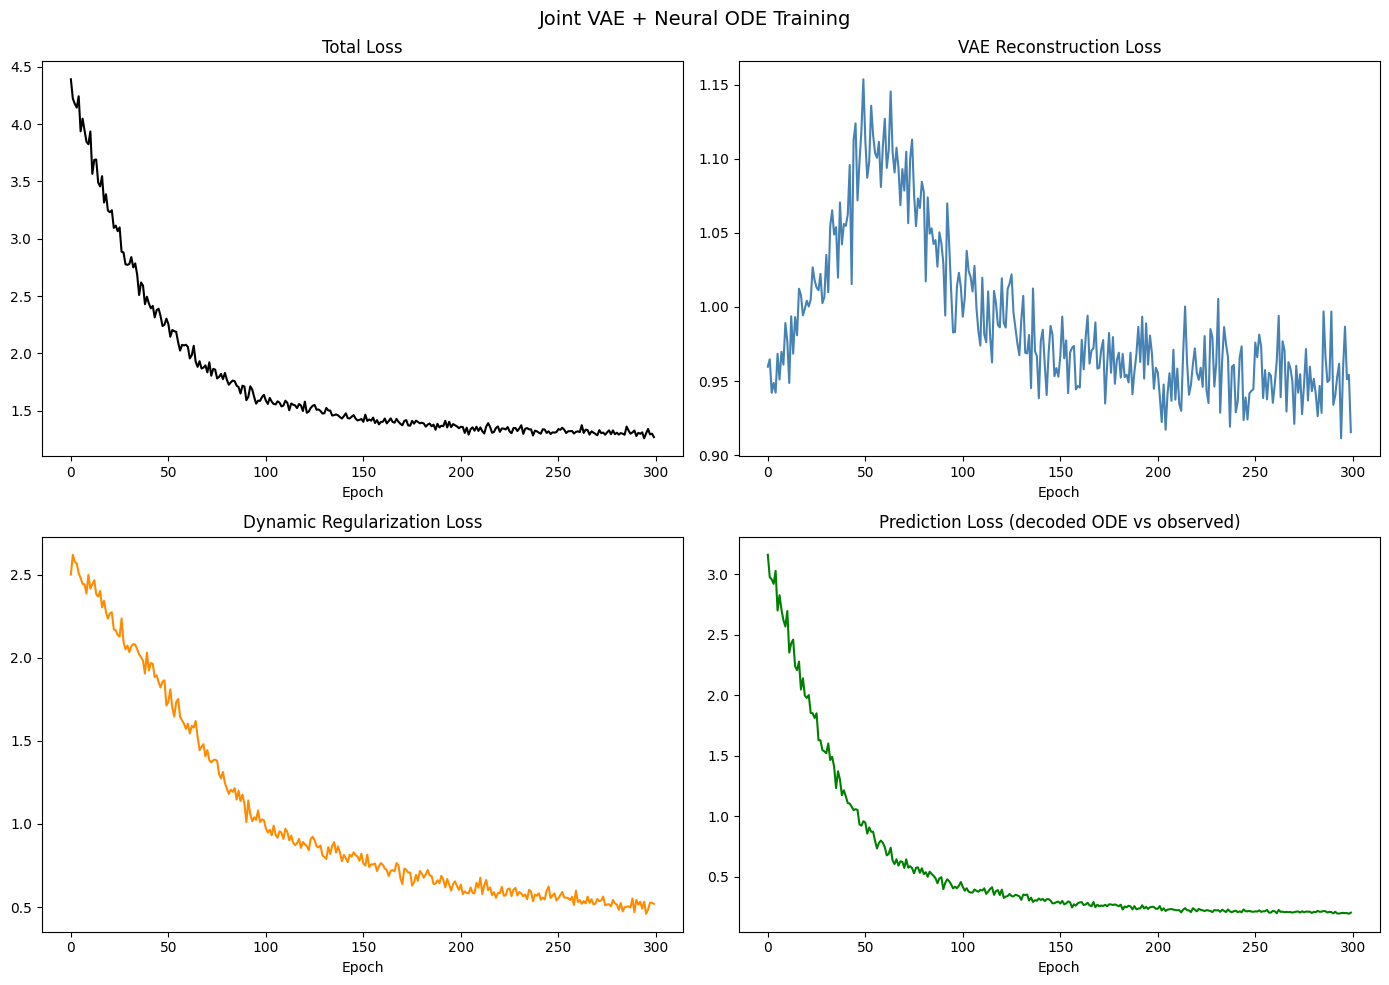

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(joint_losses, color='black')
axes[0,0].set_title('Total Loss')
axes[0,0].set_xlabel('Epoch')

axes[0,1].plot(recon_losses, color='steelblue')
axes[0,1].set_title('VAE Reconstruction Loss')
axes[0,1].set_xlabel('Epoch')

axes[1,0].plot(dyn_reg_losses, color='darkorange')
axes[1,0].set_title('Dynamic Regularization Loss')
axes[1,0].set_xlabel('Epoch')

axes[1,1].plot(pred_losses, color='green')
axes[1,1].set_title('Prediction Loss (decoded ODE vs observed)')
axes[1,1].set_xlabel('Epoch')

plt.suptitle('Joint VAE + Neural ODE Training', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/05_joint_training_curves.png', dpi=150)
plt.show()

In [9]:
torch.save(vae.state_dict(), '../models/joint_vae.pt')
torch.save(ode.state_dict(), '../models/joint_ode.pt')
with open('../models/joint_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Saved joint_vae.pt, joint_ode.pt, joint_scaler.pkl")

Saved joint_vae.pt, joint_ode.pt, joint_scaler.pkl


In [12]:
vae.eval()
ode.eval()

obs_by_t_pca = {}
for t in timepoints:
    mask = labels == t
    obs_by_t_pca[t] = data[mask]  # raw unstandardized 50D PCA

print("Held-out evaluation — Joint VAE+ODE in shared 50D PCA space:")
print("-" * 60)

with torch.no_grad():
    idx0 = torch.randperm(data_by_t[0].shape[0])[:500]
    z0_input = data_by_t[0][idx0]
    mu0, log_var0 = vae.encode(z0_input)
    z0 = vae.reparameterize(mu0, log_var0)
    
    t_span_eval = torch.FloatTensor(timepoints).to(device)
    z_pred_all = odeint(ode, z0, t_span_eval, method='dopri5')

w_dists = []
for t in timepoints[1:-1]:
    t_idx = list(timepoints).index(t)
    z_pred_t = z_pred_all[t_idx]
    
    x_pred_t = vae.decode(z_pred_t).detach().cpu().numpy()
    x_pred_pca = scaler.inverse_transform(x_pred_t)
    
    obs_t = obs_by_t_pca[t]
    idx_obs = np.random.choice(len(obs_t), size=len(x_pred_pca), replace=False)
    obs_sampled = obs_t[idx_obs]
    
    w = np.mean([
        wasserstein_distance(x_pred_pca[:, d], obs_sampled[:, d])
        for d in range(50)
    ])
    w_dists.append(w)
    print(f"  t={t}: Wasserstein = {w:.4f}")

avg = np.mean(w_dists)
print(f"  Average: {avg:.4f}")
print(f"\nFinal comparison — all methods in shared 50D PCA space:")
print(f"  Neural ODE on 50D PCA (direct):      0.2242")
print(f"  Sequential VAE + ODE:                 0.7769")
print(f"  Joint VAE + ODE (this model):         {avg:.4f}")

Held-out evaluation — Joint VAE+ODE in shared 50D PCA space:
------------------------------------------------------------
  t=1: Wasserstein = 0.3349
  t=2: Wasserstein = 0.3732
  t=3: Wasserstein = 0.4150
  Average: 0.3743

Final comparison — all methods in shared 50D PCA space:
  Neural ODE on 50D PCA (direct):      0.2242
  Sequential VAE + ODE:                 0.7769
  Joint VAE + ODE (this model):         0.3743
